# Decision Tree

The idea is to train a decision tree per user. The decision tree is trained on the `big_matrix` interaction and learns to predict a like signal (`watch_ratio >= 2` as in the Kuairec paper).

For the prediction all videos of small matrix are given and the model predicts for each whether the user will like it or not.

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

from src.metrics import ClassificationMetrics
from src.utils import *

---

# Data reading and preprocessing

We first read all the data

In [2]:
COLS = ["user_id", "video_id", "timestamp", "watch_ratio"]

X_train = read_matrix("big", "big_matrix")[COLS]
X_val = read_matrix("small", "small_matrix")[COLS]
item_categories = read_matrix("item categories", "item_categories")
item_categories["feat"] = item_categories["feat"].apply(eval)

--- Reading big matrix ---
Loading...
Cleaning...
7.71% of the data has been filtered out
--- Readed in 18.7877s ---
--- Reading small matrix ---
Loading...
Cleaning...
3.89% of the data has been filtered out
--- Readed in 6.3991s ---
--- Reading item categories matrix ---
Loading...
Cleaning...
0.00% of the data has been filtered out
--- Readed in 0.0037s ---


---

We expand the feature lists from `item_categories.csv` into four distinct columns: `feat0`, `feat1`, `feat2`, and `feat3`.

Since some videos have fewer than four associated features, we pad the list with `-124`, which is also used elsewhere in the dataset to denote missing values.

Finally, we reattach the corresponding `video_id` to preserve alignment.

In [3]:
# Split the column
expanded = item_categories['feat'].apply(lambda x: pd.Series(x + [-124]*(4 - len(x))))
expanded.columns = ['feat0', 'feat1', 'feat2', 'feat3']

# Merge to get video_id
expanded["video_id"] = item_categories["video_id"]
expanded

,feat0,feat1,feat2,feat3,video_id
0,8,-124,-124,-124,0
1,27,9,-124,-124,1
2,9,-124,-124,-124,2
3,26,-124,-124,-124,3
4,5,-124,-124,-124,4
...,...,...,...,...,...
10723,11,-124,-124,-124,10723
10724,2,-124,-124,-124,10724
10725,15,-124,-124,-124,10725
10726,19,-124,-124,-124,10726


---

# Data Exploration

In this section, we analyze the distribution of categorical features used in the recommender system.

1. **Feature Value Distributions**:  
   We examine four categorical features (`feat0` to `feat3`) extracted from the `item_categories.csv` file. For each feature:
   - We exclude placeholder values (`-124`: represent missing data).
   - We then visualize the frequency of each valid feature value using bar charts to understand their distributions across the dataset.

2. **Feature Count per Item**:  
   Next, we calculate how many features are associated with each video. We plot the distribution (on a logarithmic scale) to understand how rich the feature representation is per video.

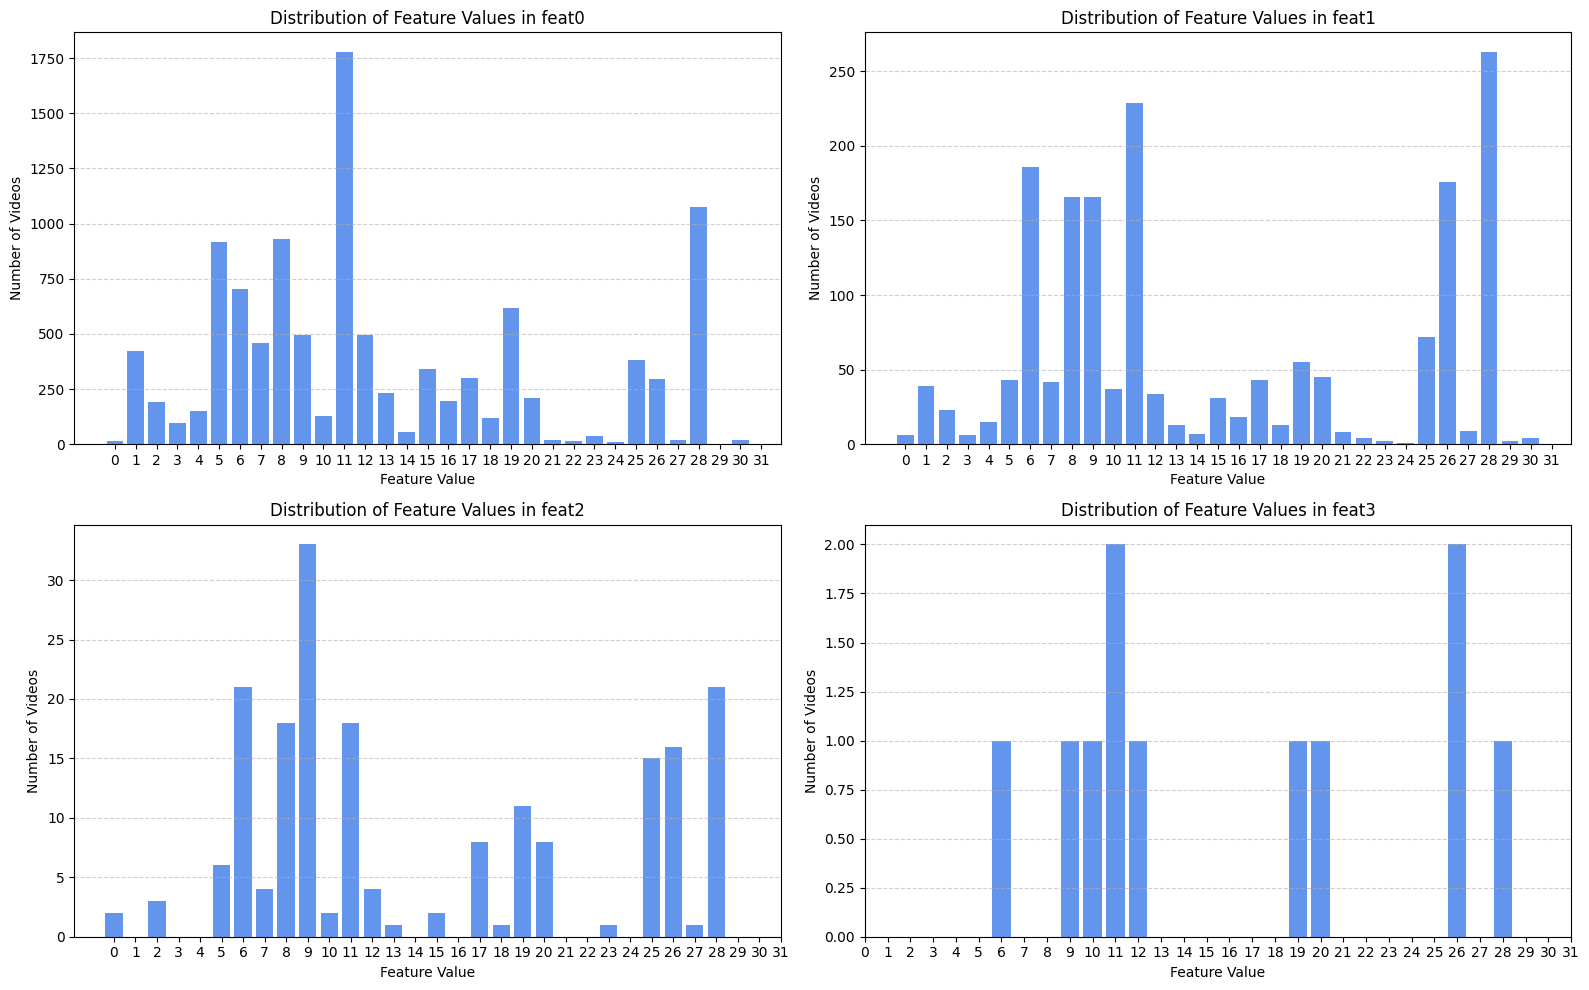

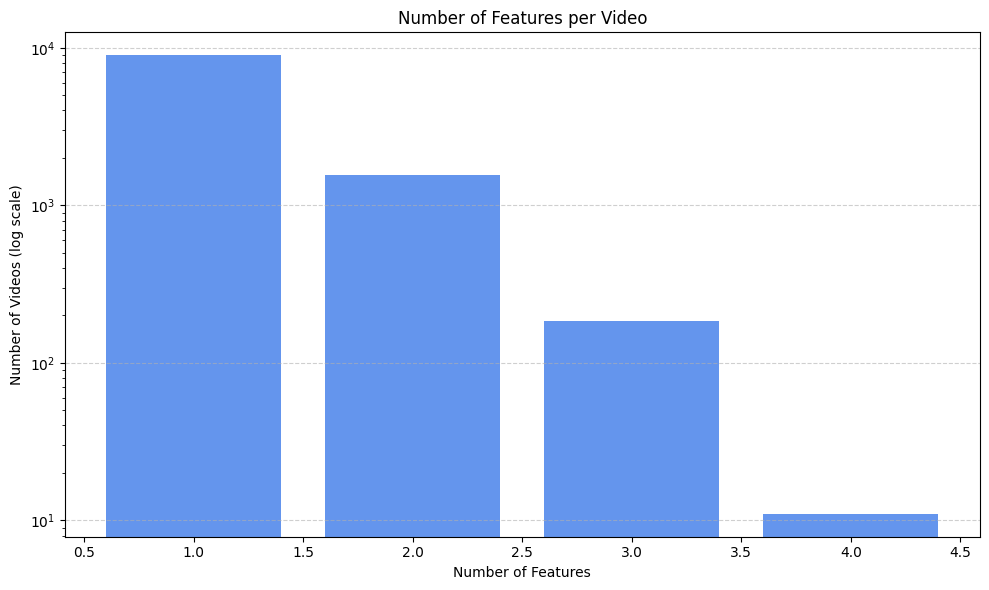

In [4]:
feature_cols = ["feat0", "feat1", "feat2", "feat3"]

plt.figure(figsize=(16, 10))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)  # 2 rows, 2 cols
    # Count values, excluding -124
    counts = expanded[expanded[col] != -124][col].value_counts().sort_index()
    plt.bar(counts.index, counts.values, color='cornflowerblue')
    plt.title(f"Distribution of Feature Values in {col}")
    plt.xlabel("Feature Value")
    plt.ylabel("Number of Videos")
    plt.xticks(range(0, 32))
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

item_categories["len"] = item_categories["feat"].apply(len)

plt.figure(figsize=(10, 6))

counts = item_categories["len"].value_counts().sort_index()
plt.bar(counts.index, counts.values, color='cornflowerblue', log=True)
plt.title("Number of Features per Video")
plt.xlabel("Number of Features")
plt.ylabel("Number of Videos (log scale)")
#plt.xticks(range(0, 32))
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---

## Per-User Decision Tree

**Data Preparation**  
The `retrieve()` function extracts interactions for a given `user_id`:
- It returns `X`: feature data for videos the user has interacted with, merged with the expanded features.
- It returns `y`: a binary label indicating whether the user "liked" each video (defined as `watch_ratio >= 2`).

**Training & Evaluation Loop**  
For each unique user in the validation set:
- We train a `DecisionTreeClassifier` on the user's training interactions.
- We then predict "liked" items in the validation set using the model.
- Predictions are compared to the actual liked items (`y_test`) and passed to the `ClassificationMetrics` object for evaluation.

Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1411/1411 [00:25<00:00, 54.65it/s]


Accuracy: 0.9991
F1-score: 0.9868
AUC: 0.9928
Recall@K: 0.1750
HitRate@K: 1.0000


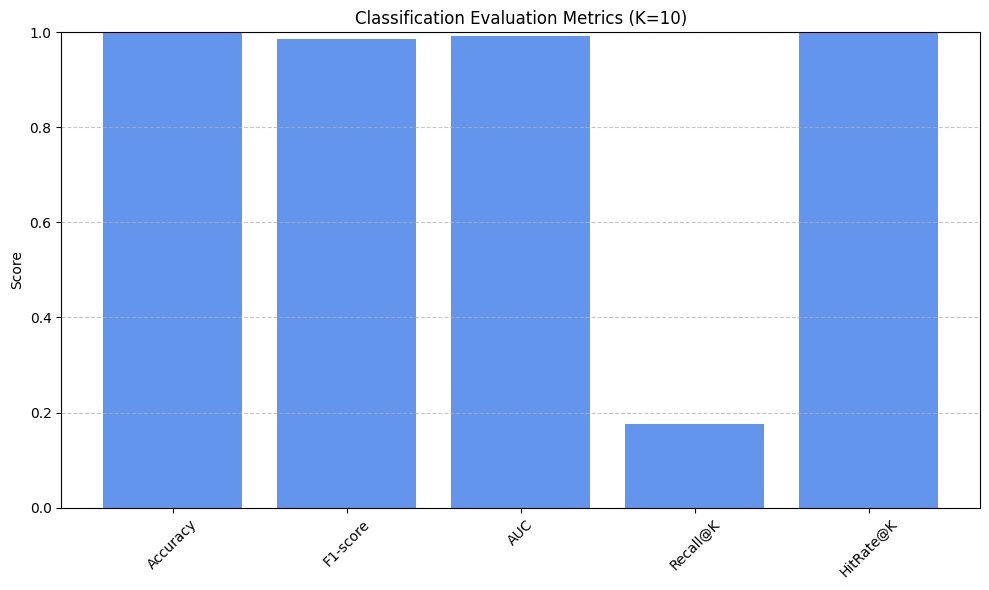

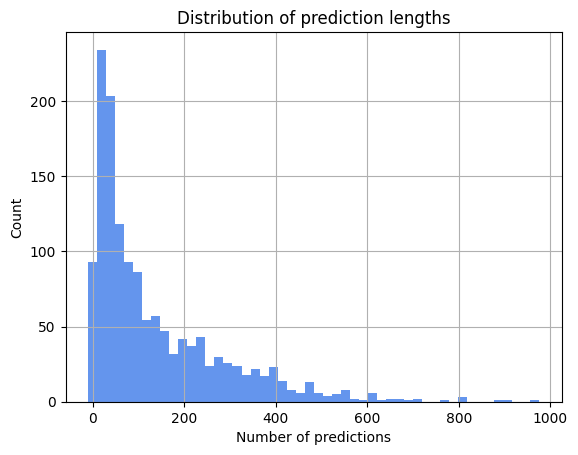

In [5]:
K=10
reco = ClassificationMetrics(K)

# Returns (X, y) where X are interactions user_id made and y is a mask indicating
# which interaction is a liking one
def retrieve(matrix, user_id):
    user_items = matrix[matrix["user_id"] == user_id][["video_id", "watch_ratio"]]

    y = user_items["watch_ratio"] >= 2
    y.reset_index(drop=True, inplace=True)
    X = user_items.merge(expanded, on="video_id")
    X.reset_index(drop=True, inplace=True)

    return X, y

for user_id in tqdm(X_val['user_id'].unique(), desc="Evaluating"):
    # We get our data and then train our decision tree
    X_train_user, y_train_user = retrieve(X_train, user_id)
    
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train_user, y_train_user)
    
    # We get our test data and predict
    X_test, y_test = retrieve(X_val, user_id)
    y_pred = clf.predict(X_test)

    # We convert it to a list of video_id
    #liked_items = X_test[y_test]["video_id"].tolist()
    #recommended_items = X_test[y_pred]["video_id"].tolist()

    # Some metrics stuff
    reco.add_evaluation(y_test, y_pred)

reco.plot()

# Conclusion

The decision tree classifier demonstrates strong performance across various evaluation metrics.

The low recall can be attributed to the **imbalance in user interaction distributions**. Some users have only a handful of liked items, while others have thousands. This uneven distribution makes the calcul of Recall meaningless since it's difficult to find a good K that match most user recommendation and not supress right accuracy for users with low like.

## Feature Engineering Process
We initially experimented with a rich set of features:
- **`item_daily_features.csv`**: Aggregated over time, capturing activity signals like `collect_cnt`, `like_cnt`, and `show_cnt`.
- **`kuairec_caption_category.csv`**: Provided additional semantic signals. For example category and caption text that we encoded using TF-IDF.

Despite these efforts, we observed that:
- Using only features from **`item_categories.csv`** produced comparable or better results.

At first, we applied **one-hot encoding**, considering there were at most 31 unique category values. However, we found that **removing one-hot encoding improved performance**. This suggests the categorical values may encode more than simple groupings—possibly rankings or some latent order that is better preserved with direct integer input.

---

# Limitations

#### Per-User Model Design
Each user has a dedicated model, which:
- Improves personalization and model precision.
- Comes with **significant memory overhead**.
- Is feasible for small datasets but **scales poorly** to large platforms with millions of users.

While optimizations such as training once per day and caching recommendations can help, this architecture is **not sustainable in production-scale environments**.

#### Binary vs. Ranking
The current model is a **binary classifier**, which:
- Decides if a user would like an item or not.
- **Does not handle ranking**, which is critical in recommendation systems.
- **Lacks contextual awareness**—for example, recommending long documentaries in the morning when users prefer short content is not meaningful, even if they like documentaries in general.